<a href="https://colab.research.google.com/github/yamnatt/winsight/blob/main/WinSight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving IPL_Ball_by_Ball_2008_2022.csv to IPL_Ball_by_Ball_2008_2022.csv
Saving IPL_Matches_2008_2022.csv to IPL_Matches_2008_2022.csv


In [ ]:
import pandas as pd

matches = pd.read_csv('IPL_Matches_2008_2022.csv')
balls = pd.read_csv('IPL_Ball_by_Ball_2008_2022.csv')


In [ ]:
print(matches.shape)
print(balls.shape)

print(matches.columns)
print(balls.columns)

(950, 20)
(225954, 17)
Index(['ID', 'City', 'Date', 'Season', 'MatchNumber', 'Team1', 'Team2',
       'Venue', 'TossWinner', 'TossDecision', 'SuperOver', 'WinningTeam',
       'WonBy', 'Margin', 'method', 'Player_of_Match', 'Team1Players',
       'Team2Players', 'Umpire1', 'Umpire2'],
      dtype='object')
Index(['ID', 'innings', 'overs', 'ballnumber', 'batter', 'bowler',
       'non-striker', 'extra_type', 'batsman_run', 'extras_run', 'total_run',
       'non_boundary', 'isWicketDelivery', 'player_out', 'kind',
       'fielders_involved', 'BattingTeam'],
      dtype='object')


#Toss winner also wins match?

In [ ]:


toss_win_match_win = (
    matches[matches['TossWinner'] == matches['WinningTeam']]
    .shape[0]
)

total_matches = matches.shape[0]

percentage = round((toss_win_match_win / total_matches) * 100, 2)

print("Total Matches:", total_matches)
print("Toss Winner Also Won:", toss_win_match_win)
print("Percentage:", percentage, "%")

Total Matches: 950
Toss Winner Also Won: 489
Percentage: 51.47 %


#Toss Desicion Analysis

In [ ]:
import pandas as pd

toss_decision_analysis = pd.crosstab(
    matches['TossDecision'],
    matches['WinningTeam'].notna()
)

print(matches['TossDecision'].value_counts())

TossDecision
field    599
bat      351
Name: count, dtype: int64


#Visualize Toss Decisions

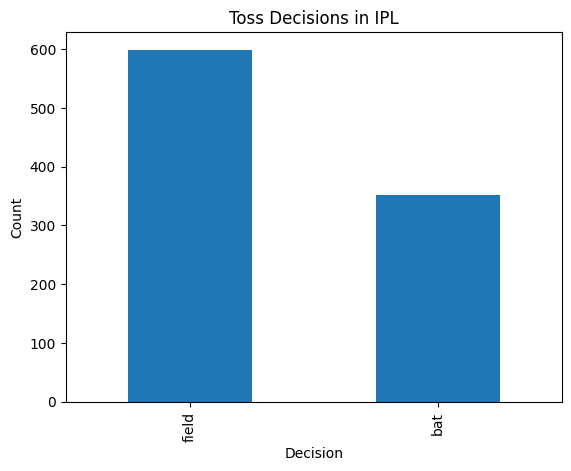

In [ ]:
import matplotlib.pyplot as plt

matches['TossDecision'].value_counts().plot(kind='bar')

plt.title("Toss Decisions in IPL")
plt.xlabel("Decision")
plt.ylabel("Count")
plt.show()

# **First Innings Score vs Winning Probability**

# First innings score for every match

In [ ]:
first_innings = balls[balls['innings'] == 1]

first_innings_score = (
    first_innings.groupby('ID')['total_run']
    .sum()
    .reset_index()
)

first_innings_score.columns = ['ID', 'FirstInningsScore']

first_innings_score.head()

,ID,FirstInningsScore
0,335982,222
1,335983,240
2,335984,129
3,335985,165
4,335986,110


In [ ]:
score_analysis = first_innings_score.merge(
    matches[['ID', 'WinningTeam']],
    on='ID'
)

score_analysis.head()

,ID,FirstInningsScore,WinningTeam
0,335982,222,Kolkata Knight Riders
1,335983,240,Chennai Super Kings
2,335984,129,Delhi Daredevils
3,335985,165,Royal Challengers Bangalore
4,335986,110,Kolkata Knight Riders


In [ ]:
score_analysis['ScoreBucket'] = pd.cut(
    score_analysis['FirstInningsScore'],
    bins=[0,140,160,180,200,300],
    labels=['<140','140-160','160-180','180-200','200+']
)

score_analysis.head()

,ID,FirstInningsScore,WinningTeam,ScoreBucket
0,335982,222,Kolkata Knight Riders,200+
1,335983,240,Chennai Super Kings,200+
2,335984,129,Delhi Daredevils,<140
3,335985,165,Royal Challengers Bangalore,160-180
4,335986,110,Kolkata Knight Riders,<140


In [ ]:
print(
    score_analysis['ScoreBucket']
    .value_counts()
    .sort_index()
)

ScoreBucket
<140       210
140-160    223
160-180    255
180-200    170
200+        92
Name: count, dtype: int64


##Win Probability


In [ ]:
# First innings team for every match

first_innings_team = (
    first_innings.groupby('ID')['BattingTeam']
    .first()
    .reset_index()
)

# Merge everything

score_analysis = score_analysis.merge(
    first_innings_team,
    on='ID'
)

# Did the first innings team win?

score_analysis['DefendedSuccessfully'] = (
    score_analysis['BattingTeam']
    == score_analysis['WinningTeam']
)

# Win % by score bucket

win_prob = (
    score_analysis.groupby('ScoreBucket')['DefendedSuccessfully']
    .mean()
    .reset_index()
)

win_prob['WinPercentage'] = round(
    win_prob['DefendedSuccessfully'] * 100,
    2
)

print(win_prob[['ScoreBucket','WinPercentage']])

  ScoreBucket  WinPercentage
0        <140          17.62
1     140-160          31.84
2     160-180          51.76
3     180-200          62.35
4        200+          85.87


/tmp/ipykernel_2855/3499155018.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  score_analysis.groupby('ScoreBucket')['DefendedSuccessfully']


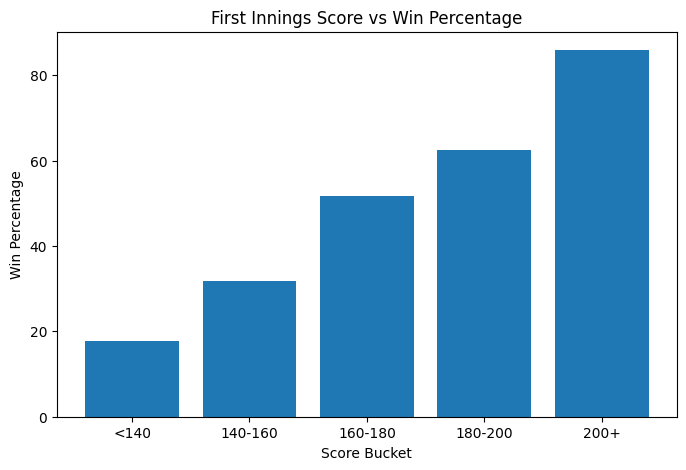

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    win_prob['ScoreBucket'].astype(str),
    win_prob['WinPercentage']
)

plt.title('First Innings Score vs Win Percentage')
plt.xlabel('Score Bucket')
plt.ylabel('Win Percentage')

plt.show()

# **Powerplay Efficiency**

# Powerplay runs for each match

In [ ]:


powerplay = balls[balls['overs'] <= 6]

powerplay_runs = (
    powerplay.groupby('ID')['total_run']
    .sum()
    .reset_index()
)

powerplay_runs.columns = ['ID', 'PowerplayRuns']

powerplay_runs.head()

,ID,PowerplayRuns
0,335982,101
1,335983,131
2,335984,103
3,335985,100
4,335986,78


In [ ]:
powerplay_analysis = powerplay_runs.merge(
    first_innings_team,
    on='ID'
)

powerplay_analysis = powerplay_analysis.merge(
    matches[['ID', 'WinningTeam']],
    on='ID'
)

powerplay_analysis['WonMatch'] = (
    powerplay_analysis['BattingTeam']
    == powerplay_analysis['WinningTeam']
)

powerplay_analysis.head()

,ID,PowerplayRuns,BattingTeam,WinningTeam,WonMatch
0,335982,101,Kolkata Knight Riders,Kolkata Knight Riders,True
1,335983,131,Chennai Super Kings,Chennai Super Kings,True
2,335984,103,Rajasthan Royals,Delhi Daredevils,False
3,335985,100,Mumbai Indians,Royal Challengers Bangalore,False
4,335986,78,Deccan Chargers,Kolkata Knight Riders,False


In [ ]:
powerplay_analysis['PPBucket'] = pd.cut(
    powerplay_analysis['PowerplayRuns'],
    bins=[0,40,50,60,70,200],
    labels=['<40','40-50','50-60','60-70','70+']
)

#Calculate Win %

In [ ]:
pp_win = (
    powerplay_analysis.groupby('PPBucket')['WonMatch']
    .mean()
    .reset_index()
)

pp_win['WinPercentage'] = round(
    pp_win['WonMatch'] * 100,
    2
)

print(pp_win[['PPBucket','WinPercentage']])

  PPBucket  WinPercentage
0      <40           0.00
1    40-50            NaN
2    50-60          50.00
3    60-70          35.00
4      70+          44.95


/tmp/ipykernel_2855/4241854450.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  powerplay_analysis.groupby('PPBucket')['WonMatch']


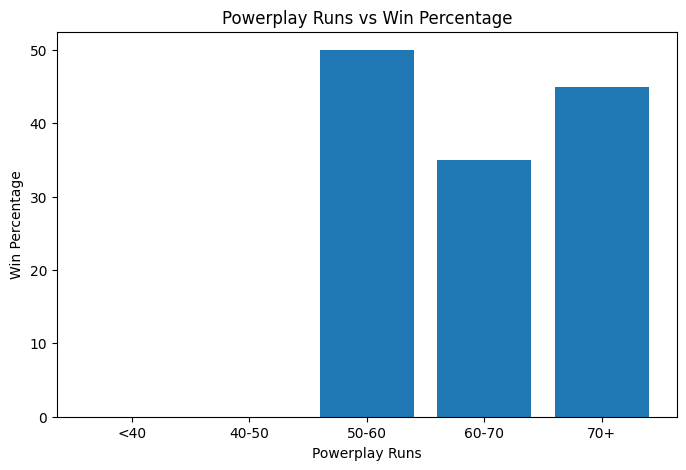

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    pp_win['PPBucket'].astype(str),
    pp_win['WinPercentage']
)

plt.title('Powerplay Runs vs Win Percentage')
plt.xlabel('Powerplay Runs')
plt.ylabel('Win Percentage')

plt.show()

In [ ]:
powerplay_analysis['PowerplayRuns'].describe()

,PowerplayRuns
count,950.000000
mean,105.393684
std,20.020347
min,38.000000
25%,91.000000
50%,104.000000
75%,118.000000
max,184.000000


In [ ]:
powerplay_analysis['PowerplayRuns'].value_counts().sort_index().head(20)

,count
PowerplayRuns,
38,1
52,1
56,1
57,2
58,1
59,3
61,1
62,1
63,1


In [ ]:
first_innings_pp = balls[
    (balls['innings'] == 1) &
    (balls['overs'] <= 6)
]

pp_runs = (
    first_innings_pp
    .groupby('ID')['total_run']
    .sum()
    .reset_index()
)

pp_runs.columns = ['ID', 'PowerplayRuns']

pp_runs = pp_runs.merge(
    first_innings_team,
    on='ID'
)

pp_runs = pp_runs.merge(
    matches[['ID','WinningTeam']],
    on='ID'
)

pp_runs['WonMatch'] = (
    pp_runs['BattingTeam'] ==
    pp_runs['WinningTeam']
)

pp_runs.groupby('WonMatch')['PowerplayRuns'].mean()

,PowerplayRuns
WonMatch,
False,48.940952
True,54.929412


In [ ]:
balls[balls['overs'] <= 6]

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225894,335982,2,6,4,MV Boucher,AB Agarkar,CL White,wides,0,1,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore
225895,335982,2,6,5,MV Boucher,AB Agarkar,CL White,wides,0,1,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore
225896,335982,2,6,6,MV Boucher,AB Agarkar,CL White,NaN,0,0,0,0,0,NaN,NaN,NaN,Royal Challengers Bangalore
225897,335982,2,6,7,MV Boucher,AB Agarkar,CL White,NaN,0,0,0,0,0,NaN,NaN,NaN,Royal Challengers Bangalore


In [ ]:
balls['overs'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

In [ ]:
sorted(balls['overs'].unique())[:10]

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9)]

In [ ]:
first_innings_pp = balls[
    (balls['innings'] == 1) &
    (balls['overs'] <= 5)
]

pp_runs = (
    first_innings_pp
    .groupby('ID')['total_run']
    .sum()
    .reset_index()
)

pp_runs.columns = ['ID', 'PowerplayRuns']

print(pp_runs['PowerplayRuns'].describe())

count    950.000000
mean      45.064211
std       11.337298
min       15.000000
25%       37.000000
50%       45.000000
75%       52.000000
max       84.000000
Name: PowerplayRuns, dtype: float64


#Calculate Death over run

In [ ]:
death_overs = balls[
    (balls['innings'] == 1) &
    (balls['overs'] >= 15)
]

death_runs = (
    death_overs.groupby('ID')['total_run']
    .sum()
    .reset_index()
)

death_runs.columns = ['ID', 'DeathRuns']

death_runs.head()

,ID,DeathRuns
0,335982,68
1,335983,79
2,335984,33
3,335985,60
4,335986,33


In [ ]:
death_analysis = death_runs.merge(
    first_innings_team,
    on='ID'
)

death_analysis = death_analysis.merge(
    matches[['ID','WinningTeam']],
    on='ID'
)

death_analysis['WonMatch'] = (
    death_analysis['BattingTeam']
    ==
    death_analysis['WinningTeam']
)

In [ ]:
death_analysis.groupby('WonMatch')['DeathRuns'].mean()

,DeathRuns
WonMatch,
False,45.298450
True,54.530806


# **Venue Analysis**

In [ ]:
venue_stats = matches.groupby('Venue').agg(
    Matches=('ID','count')
).reset_index()

venue_stats = venue_stats.sort_values(
    by='Matches',
    ascending=False
)

print(venue_stats.head(10))

                                         Venue  Matches
11                                Eden Gardens       77
46                            Wankhede Stadium       73
19                       M Chinnaswamy Stadium       65
13                            Feroz Shah Kotla       60
35   Rajiv Gandhi International Stadium, Uppal       49
22             MA Chidambaram Stadium, Chepauk       48
38                      Sawai Mansingh Stadium       47
10         Dubai International Cricket Stadium       46
33  Punjab Cricket Association Stadium, Mohali       35
47                    Wankhede Stadium, Mumbai       31


#Highest Scoring Venues

In [ ]:
venue_scores = first_innings_score.merge(
    matches[['ID','Venue']],
    on='ID'
)

venue_avg = (
    venue_scores.groupby('Venue')['FirstInningsScore']
    .mean()
    .sort_values(ascending=False)
)

print(venue_avg.head(10))

Venue
Eden Gardens, Kolkata                            197.500000
Arun Jaitley Stadium, Delhi                      195.000000
Brabourne Stadium                                180.400000
Brabourne Stadium, Mumbai                        177.411765
Himachal Pradesh Cricket Association Stadium     175.666667
Punjab Cricket Association IS Bindra Stadium     175.600000
M.Chinnaswamy Stadium                            173.933333
Maharashtra Cricket Association Stadium, Pune    171.461538
Dr DY Patil Sports Academy, Mumbai               170.700000
Wankhede Stadium, Mumbai                         169.935484
Name: FirstInningsScore, dtype: float64


#Franchise Comarison

In [ ]:
all_teams = pd.concat([
    matches['Team1'],
    matches['Team2']
])

team_matches = all_teams.value_counts()

team_wins = matches['WinningTeam'].value_counts()

team_stats = pd.DataFrame({
    'Matches': team_matches,
    'Wins': team_wins
}).fillna(0)

team_stats['WinPercentage'] = round(
    team_stats['Wins'] /
    team_stats['Matches'] * 100,
    2
)

team_stats = team_stats.sort_values(
    by='WinPercentage',
    ascending=False
)

print(team_stats.head(10))

                             Matches  Wins  WinPercentage
Gujarat Titans                    16    12          75.00
Rising Pune Supergiant            16    10          62.50
Lucknow Super Giants              15     9          60.00
Chennai Super Kings              208   121          58.17
Delhi Capitals                    63    36          57.14
Mumbai Indians                   231   131          56.71
Kolkata Knight Riders            223   114          51.12
Rajasthan Royals                 192    96          50.00
Sunrisers Hyderabad              152    75          49.34
Royal Challengers Bangalore      226   109          48.23


In [ ]:
season_scores = first_innings_score.merge(
    matches[['ID','Season']],
    on='ID'
)

season_avg = (
    season_scores.groupby('Season')['FirstInningsScore']
    .mean()
    .reset_index()
)

print(season_avg)

     Season  FirstInningsScore
0   2007/08         160.965517
1      2009         150.263158
2   2009/10         164.783333
3      2011         152.369863
4      2012         157.540541
5      2013         155.894737
6      2014         163.066667
7      2015         166.254237
8      2016         162.600000
9      2017         165.779661
10     2018         172.466667
11     2019         166.733333
12  2020/21         169.500000
13     2021         159.316667
14     2022         171.121622


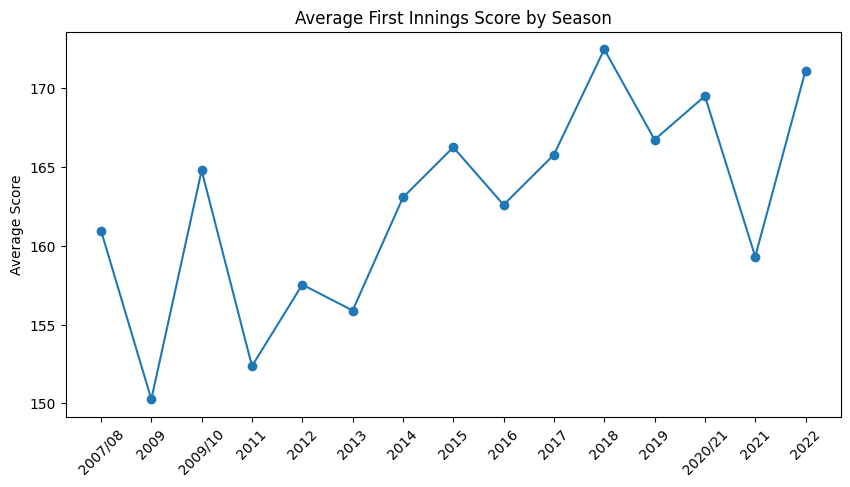

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    season_avg['Season'],
    season_avg['FirstInningsScore'],
    marker='o'
)

plt.xticks(rotation=45)
plt.title('Average First Innings Score by Season')
plt.ylabel('Average Score')
plt.show()

#Toss Impact

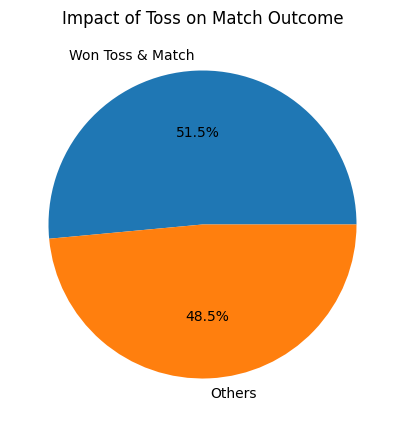

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.pie(
    [489,950-489],
    labels=['Won Toss & Match','Others'],
    autopct='%1.1f%%'
)

plt.title('Impact of Toss on Match Outcome')
plt.show()

#Deth over impact

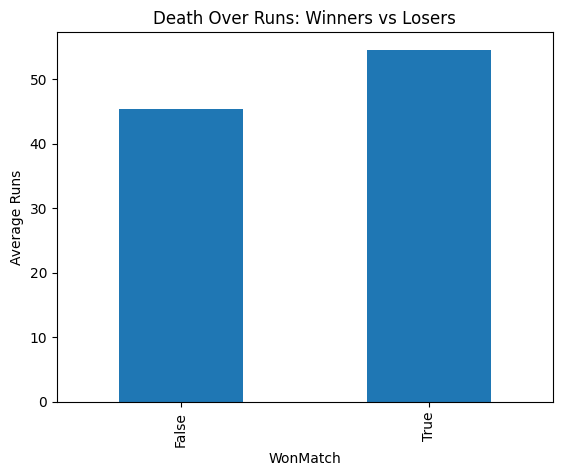

In [ ]:
death_analysis.groupby('WonMatch')['DeathRuns'].mean().plot(
    kind='bar'
)

plt.title('Death Over Runs: Winners vs Losers')
plt.ylabel('Average Runs')
plt.show()

#Top Teams by Win %

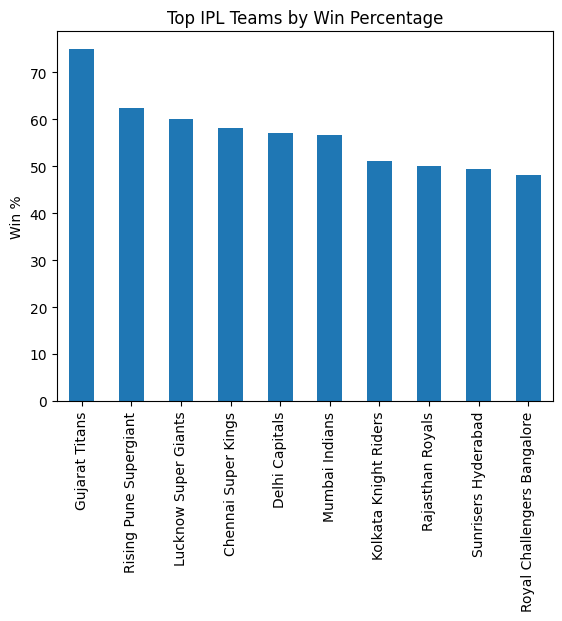

In [ ]:
team_stats.head(10)['WinPercentage'].plot(
    kind='bar'
)

plt.title('Top IPL Teams by Win Percentage')
plt.ylabel('Win %')
plt.show()